Intro to Python continued. Adapted from content created by James Murray.

# 7. Numpy arrays

Remember that Python is a general-purpose programming language. Numerical and scientific computing is just one of the many things that it can do. The part of Python that is specialized for numerical computation is called Numpy, and it is a collection (or "library") of functions and objects that allow us to do things like generate random numbers, take averages, and lots of other useful things.

Two things are especially important when using Numpy. First, if we want to use functions or objects from numpy, we need to *import* Numpy. This is usually done at the top of a notebook or script, but can be done anywhere.


In [1]:
import numpy as np

The second important thing is that, in order to use a function or object from Numpy, we need to precede it with `np.`, which tells Python that we are asking for something that is part of Numpy. So, for example, the circumference of the unit circle is given by the following, where we make use of the special variable `pi` that is part of Numpy:

In [2]:
2*np.pi

6.283185307179586

Note that the last part of our import statement above, `as np` just introduces a shorthand for Numpy, allowing us to write, for example, `np.pi` rather than `numpy.pi`.

Numpy **arrays** can be thought of as vectors or matrices (or their higher-dimensional generalizations). The data that we analyze throughout this course will generally be stored as arrays, so learning how to understand and manipulate them is very important.

## Creating new arrays and indexing

Arrays can be created by hand as follows:

In [3]:
# a one-dimensional array, i.e. a vector:
a1 = np.array([1,3,5,7,9])
print(a1)

# a two-dimensional array, i.e. a matrix:
a2 = np.array([[2, 4, 6],  # Note that we are allowed to continue on the next line if inside of a parenthesis
               [8, 10, 12]])
print(a2)

[1 3 5 7 9]
[[ 2  4  6]
 [ 8 10 12]]


As we did with lists above, we can use square brackets to obtain just part of an array. First, let's use indices to get individual elements of an array.

In [4]:
a1 = np.array([1,3,5,7,9])
print(a1[0])  # remember that indexing starts with 0, not 1!
print(a1[1])
print(a1[2])

1
3
5


As with lists, we can also count backwards from the end with negative indices.

In [5]:
print(a1[-1])
print(a1[-2])
print(a1[-3])

9
7
5


We can use this type of indexing to reassign elements in an array, as in the following examples.

In [6]:
a1 = np.array([1,3,5,7,9])
print(a1)  # the array before making any changes

a1[0] = 42  # change the first element and print the result
print(a1)

a1[-1] = 43  # change the last element and print the result
print(a1)

[1 3 5 7 9]
[42  3  5  7  9]
[42  3  5  7 43]


We can also "slice" an array, where a **slice** refers to a range of incides. The slice `[i:j]` returns a smaller array that starts with the `i`th entry (including this entry) and continues to the `j`th entry (not including this entry). (Remember that indexes start from 0, not 1!)

In [7]:
print(a1[2:4])

[5 7]


Similarly, we can use `[:i]` to return all of the elements up to (but not including) index `i`, or `[i:]` to return all of the elements starting from (and including) index `i`, as in the following examples.

In [8]:
a1 = np.array([1,3,5,7,9])
print(a1[:2])
print(a1[2:])

[1 3]
[5 7 9]


Just as we were able to reassign individual elements in an array above, we can reassign slices in the same way.

In [9]:
a1[:2] = np.array([23, 45])
print(a1)

[23 45  5  7  9]


For a multidimensional array, indices along each dimension should be separated by a comma. For a two-dimensional array, the first index refers to the row, and the second to the column.

In [10]:
a2 = np.array([[2, 4, 6],
              [8, 10, 12]])
print(a2)
print(a2[0,1])

[[ 2  4  6]
 [ 8 10 12]]
4


We can also get an entire row or an entire column of a two-dimensional array as in the following example. Here, we can think of `:` as a slice that includes all elements.

In [11]:
print(a2)
print(a2[0,:])  # print the first (i.e. 0th) row
print(a2[:,-1])  # print the last column

[[ 2  4  6]
 [ 8 10 12]]
[2 4 6]
[ 6 12]


It is often useful to ask how long an array is along each dimension.

In [12]:
print(np.shape(a1))  # for a one-dimensional array, we could also use len(a1)
print(np.shape(a2)) # shape is the length of multi-dimensional array, with a 1-D array you'll get (5,), 2-D array you'll get both (R,C)

(5,)
(2, 3)


One common way to quickly create a new array is to fill it with zeros, as follows, where the argument gives the length of the array:

In [13]:
a3 = np.zeros(5) #5 columns all 0, 1 row
print(a3)

[0. 0. 0. 0. 0.]


If we want to create a two-dimensional array (i.e. a matrix) filled with zeros, the argument should give the dimensions as `(dim1, dim2)`.

In [14]:
a4 = np.zeros((3,5)) #(R, C)
print(a4)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


If we want the array to have uniform nonzero values, we can similarly use `np.ones`.

In [15]:
a5 = np.ones(5)
print('A vector of ones:')
print(a5)

a6 = 7*np.ones((3,5))
print('A matrix of sevens:')
print(a6)

A vector of ones:
[1. 1. 1. 1. 1.]
A matrix of sevens:
[[7. 7. 7. 7. 7.]
 [7. 7. 7. 7. 7.]
 [7. 7. 7. 7. 7.]]


Why would we want to have an array full of zeros or ones? A common thing to do is to initialize an array this way, then to change the elements one-by-one to the values that we want, according to some rule. This is often done with a for loop. In the following example, we'll make an array with the squares of all of the integers from 1 to 10.

In [16]:
squares = np.zeros(10) #[0,0,0,0,0,0,0,0,0,0]

for i in range(10): #looping through the array 10 times, each time modifying a particular entry of that array, indices start at 0 so i+1 to get out of squaring the 0.
    squares[i] = (i+1)**2  # use i+1 here since we want to start from 1, not 0

print(squares)

[  1.   4.   9.  16.  25.  36.  49.  64.  81. 100.]


Or, in the next example, we can use nested for loops to generate a multiplication table.

In [17]:
mult_table = np.zeros((10, 10)) #10x10 zero matrix, loop through each row anad then  (R,C)

for row in range(10):
    for column in range(10):
        mult_table[row,column] = (row+1)*(column+1)

print(mult_table)

[[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.]
 [  2.   4.   6.   8.  10.  12.  14.  16.  18.  20.]
 [  3.   6.   9.  12.  15.  18.  21.  24.  27.  30.]
 [  4.   8.  12.  16.  20.  24.  28.  32.  36.  40.]
 [  5.  10.  15.  20.  25.  30.  35.  40.  45.  50.]
 [  6.  12.  18.  24.  30.  36.  42.  48.  54.  60.]
 [  7.  14.  21.  28.  35.  42.  49.  56.  63.  70.]
 [  8.  16.  24.  32.  40.  48.  56.  64.  72.  80.]
 [  9.  18.  27.  36.  45.  54.  63.  72.  81.  90.]
 [ 10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]]


Although we have just considered one- and two-dimensional arrays so far, they can have arbitrary dimension (though they get harder to visualize as the dimension gets higher). Here we'll make a three-dimensional array of zeros and print its shape.

In [18]:
a7 = np.zeros((3,4,5)) # of Dimensions, # Rows of Each Dimension, # Columns of Each Dimensions
print(a7) #3-D arrays, not 3 entries 3 dimentions: 
print(np.shape(a7))

[[[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]]
(3, 4, 5)


Another very useful way to create an array is using `arange`, which creates a one-dimensional array of ordered elements (similar to `range`, which we encountered above).

If there's one number as input, `arange` creates an array of integers up to (but not including) that number, starting from 0:

In [19]:
print(np.arange(10))

[0 1 2 3 4 5 6 7 8 9]


If there are two inputs, it creates an array of integers from the first up to (but not including) the second number:

In [20]:
print(np.arange(5, 15)) #5 up to, but not including 15

[ 5  6  7  8  9 10 11 12 13 14]


Finally, if three numbers are given as input, the third input determines the spacing between successive numbers in the array:

In [21]:
print(np.arange(0, 5, 0.2)) # 0 up to 5 with step 0.2

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8]


Another often useful way to create an array is to fill it with random values. The most common ways to do this are to use `np.random.rand` to generate random values distributed uniformly over (0,1), or `np.random.randn` to generate random values from the standard normal distribution (i.e. a bell-shaped distribution centered at 0).

In [22]:
print('A single random number: \n', np.random.rand())
print('A one-dimensional array of random numbers: \n', np.random.rand(5)) #5 random numbers from 0 to 1
print('A two-dimensional array of random numbers: \n', np.random.rand(5,5))

A single random number: 
 0.5328671438181422
A one-dimensional array of random numbers: 
 [0.87012851 0.39080775 0.95621221 0.04709197 0.35536543]
A two-dimensional array of random numbers: 
 [[0.54163763 0.90335696 0.50879721 0.91178441 0.43842662]
 [0.64130491 0.55577904 0.04760388 0.88269212 0.37970137]
 [0.69022778 0.70809393 0.43066596 0.8105087  0.90060875]
 [0.84130814 0.70815136 0.96652555 0.19059289 0.90692781]
 [0.00269971 0.80574862 0.57537216 0.58800924 0.62625781]]


## Exercises

7.1. Create a 5-by-5 array of zeros, then use a for loop to set all of the diagonal elements to 1.

In [23]:
e1 = np.zeros((5, 5))
#print(e1)

for row in range(5):
    for column in range(5):
        #e1[row, column] = (row==column)
        if row ==column:
            e1[row,column]=1
print(e1)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


7.2. Create a 5-by-5 array of zeros, then use slicing and `np.ones` to set every element in the middle column to 1.


In [24]:
e1 = np.zeros((5, 5))
e1[:, 2] = 1
print(e1) # the ":" means all rows, and the 2 means the 3rd column, so this sets all rows of the 3rd column to 1, and the rest are 0


[[0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


7.3. Create an array of zeros of length 10. Set the first element to zero and the second element to 1. Then use a for loop to set the remaining elements to the Fibonnaci sequence, in which each element is the sum of the two elements that came before it. Print the resulting array. Is the last element 34?

## Arithemetic with arrays

As mentioned above, Numpy arrays can be thought of as vectors (and their higher-dimensional counterparts).

The first important property of a vector is that we can add or subtract two vectors together and get another vector of the same shape. Vector addition just means that each component of the first vector is added to the corresponding component of the second vector, as in the following example.

In [25]:
b1 = np.arange(10.)  # Note: using 10. rather than 10 means the array is filled with float numbers rather than integers
b2 = np.ones(10) #set all columns to 1, 10 columns and 1 row
b3 = b1 + b2
print(b1)
print(b2)
print(b3)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


The second important property of a vector is that we can multiply a vector by a number and get back a vector of the same type. In this case, the number that multiplies the vector simply multiplies each individual element in the vector, as in the following example.

In [26]:
b1 = np.arange(10.)
b4 = 3*b1
print(b1)
print(b4)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27.]


Other basic arithemetic operations work in a similar way, element by element. One important thing to note is that the multiplication operator `*`, when applied to two vectors, refers to elementwise multiplication.

In [27]:
b1 = np.arange(10.)
b5 = 2*np.ones(10)
b6 = b1*b5 #takes each element and multiplies with corresponding element
print(b1)
print(b5)
print(b6)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]


This is a potential point of confusion for Matlab users, where applying the `*` operator to two vectors gives a dot product (i.e. elementwise multiplication followed by a sum over all elements) for vectors or a matrix product for products involving matrices. To take a dot product with Numpy, use either `np.dot` or `@`.

In [28]:
b7 = np.array([1., 2., 3.])
b8 = np.array([4., 5., 6.])
print(b7*b8)
print(np.dot(b7, b8)) #dot product, multiply each element and then add them together, 1*4 + 2*5 + 3*6 = 32
print(b7 @ b8)

[ 4. 10. 18.]
32.0
32.0


The extension of the above ideas to multidimensional arrays is straightforward, as illustrated by the following examples.

In [29]:
b9 = np.array([[0., 2., 4.],
              [6., 8., 10.]])
b10 = np.array([[1., 3., 5.],
                [7., 9., 11.]])

print('Addition: \n', b9 + b10)  # Note: when occurring inside of a string, `\n` means start a new line
print('Scalar multiplication: \n', -1*b9) #
print('(Elementwise) matrix multiplication: \n', b9 * b10) #

Addition: 
 [[ 1.  5.  9.]
 [13. 17. 21.]]
Scalar multiplication: 
 [[ -0.  -2.  -4.]
 [ -6.  -8. -10.]]
(Elementwise) matrix multiplication: 
 [[  0.   6.  20.]
 [ 42.  72. 110.]]


Be careful to note that, typically, only arrays of the same size can be combined. Trying to combine them will result in an error.

In [30]:
b7 = np.array([1., 2., 3.])
b10 = np.array([4., 5.])

# Uncomment the line below and run the cell to see the error message:
#print(b7 + b10)

An exception to this rule is **broadcasting**, as illustrated in the following examples.

In [31]:
# A scalar can be broadcast with a vector:

b7 = np.array([1., 2., 3.])
b11 = 1.5 + b7  # The same value (1.5) is "broadcast" to combine with each indivicual element of b7
print(b11)

[2.5 3.5 4.5]


In [32]:
# A vector can be broadcast with a matrix (of compatible dimensions):

b7 = np.array([1., 2., 3.])
b12 = np.array([[2, 4, 6],
              [8, 10, 12]])
b13 = b7 + b12  # The same three values from b7 are "broadcast" into each individual row of b12
print(b13)

[[ 3.  6.  9.]
 [ 9. 12. 15.]]


If broadcasting seems a bit confusing, feel free not to use it in your own code. It can be a handy shortcut, but there are always other ways to combine arrays in which broadcasting isn't necessary.

## Exercises

7.4. Use vector addition and scalar multiplication to convert the array of Celsius temperatures below to a new array of Fahrenheit temperatures and print the resulting array.

In [33]:
celsius = np.array([0., 10., 20., 30.])

### Your code here ###
f = 9/5 * celsius + 32
print(f)

[32. 50. 68. 86.]


7.5. Using `b7 = np.array([1., 2., 3.])` and `b8 = np.array([4., 5., 6.])` as above, make guesses about what answers you expect the following to give:

    - `b8 - b7` (subtraction)
    - `b7 / b8` (division)
    - `b7**2` (exponentiation)

In each case, check whether your guesses were right.

In [34]:
subtraction: [3, 3, 3]
division: [4, 2.5, 2]
exponentiation: [1, 4, 9]

## Masking and fancy indexing

A **mask** enables us to select elements of an array that satisfy a certain condition. In the example below, we will select just the even elements in an array.

In [35]:
b14 = np.arange(10) #creates an array of integers from 0 to 9
print(b14) 
mask = (b14%2 == 0)  # The right hand side is True for elements that have remainder 0 when divided by 2
print(mask)


[0 1 2 3 4 5 6 7 8 9]
[ True False  True False  True False  True False  True False]


Now we can use this mask to select only the elements of `b14` for which the condition is True.

In [36]:
print(b14[mask])

# Note that we could also get the same thing without defining mask as a variable:
print(b14[b14%2==0])

[0 2 4 6 8]
[0 2 4 6 8]


We could also choose to set the elements selected by the mask to some other value:

In [37]:
b14[mask] = np.zeros(5) # Set the elements of b14 that satisfy the condition (i.e. the even numbers) to 0, and print the result
print(b14)

[0 1 0 3 0 5 0 7 0 9]


In fact, we can do the same thing in a simpler way using broadcasting:

In [38]:
b14 = np.arange(10) #array of integers from 0 to 9
b14[mask] = 0 #sets even numbers to 0
print(b14)

[0 1 0 3 0 5 0 7 0 9]


Let's say that we have an array or list `indices_list` giving the indices that we would like to extract from another array. We can do this using **fancy indexing** as follows.

In [39]:
b15 = np.array([1, 3, 5, 7, 9])
indices_list = [0, 1, 4, 4]  # some indices of the above array that we care about
print(b15[indices_list])

# Note that we can also just skip defining indices_list and get the same result with the following:
print(b15[[0, 1, 4, 4]])

[1 3 9 9]
[1 3 9 9]


## Exercises

7.6. In an earlier exercise, we created an array of the first 10 Fibonacci numbers. Use a mask to create separate arrays of even and odd Fibonacci numbers and print the two resulting arrays.

7.7. Create an array of 20 random numbers using `np.random.randn()`. Then use a mask to set all of the negative numbers in the array to zero and print the result.

In [40]:
import numpy as np
bb = np.random.randn(20) #20 random numers from a normal distribution with mean 0 and standard deviation 1
mask = bb<0
bb[mask] = 0
print(bb)


[0.         0.         1.96113298 0.56352023 1.02639669 0.
 0.09699771 0.87097684 0.         0.         0.82153928 0.83789112
 2.32338957 0.00722524 0.         0.         1.60153566 0.
 0.         0.        ]


## Other operations on arrays

Numpy has lots of built-in functions that are useful for using with arrays. Below are a few examples.

In [41]:
b15 = np.array([1, 3, 5, 7, 9])
print(b15)
print('Mean: ', b15.mean())
print('Mean: ', np.mean(b15))
print('Max: ', np.max(b15))
print('Min: ', np.min(b15))
print('Sum: ', np.sum(b15))

[1 3 5 7 9]
Mean:  5.0
Mean:  5.0
Max:  9
Min:  1
Sum:  25


When applying operations like these to a multidimensional array, we might want to apply them separately in each row or column (i.e. along each "axis"). All of the built-in functions above can take a second argument that specifies which axis to perform the operation along.

In [42]:
b12 = np.array([[2, 4, 6],
              [8, 10, 12]])
print(b12)
print('Mean of all elements: ', np.mean(b12)) #Take all elements and sums and averages
print('Mean over columns: ', np.mean(b12, axis=0)) #Axis 0 is columns, 1 is rows
print('Mean over rows: ', np.mean(b12, axis=1))

[[ 2  4  6]
 [ 8 10 12]]
Mean of all elements:  7.0
Mean over columns:  [5. 7. 9.]
Mean over rows:  [ 4. 10.]


If a function like `np.sin` or `np.cos` is applied to an array, it operates elementwise on each element. Let's illustrate this by taking a spin around the unit circle.

In [43]:
theta_array = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
cos_theta = np.cos(theta_array)
print(cos_theta)

[ 1.0000000e+00  6.1232340e-17 -1.0000000e+00 -1.8369702e-16]


## Exercises

7.8. Use `np.arange` and `np.sum` to add up all of the numbers from 1 to 100. Check that you get the same answer this way that you got using the for loop above.

In [44]:
a = np.arange(1,101)
print(a)
print(np.sum(a))

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
5050


7.9. Use `np.random.rand()` to create an array of 1000 random numbers uniformly distributed between 0 and 1. Compute the mean first using `np.mean()` and second by using `np.sum()` and dividing by the length of the array, showing that both give the same result. Is the resulting value close to the value that you would expect?

## Getting help

If you would like to know more about a built-in Python function, just type its name followed by a question mark to view its documentation, which describes what the allowed inputs are, as well as what the function returns.

In [45]:
np.mean?

Signature:       np.mean(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function mean at 0x7c1654e5f4c0>
File:            /usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py
Docstring:      
Compute the arithmetic mean along the specified axis.

Returns the average of the array elements.  The average is taken over
the flattened array by default, otherwise over the specified axis.
`float64` intermediate and return values are used for integer inputs.

Parameters
----------
a : array_like
    Array containing numbers whose mean is desired. If `a` is not an
    array, a conversion is attempted.
axis : None or int or tuple of ints, optional
    Axis or axes along which the means are computed. The default is to
    compute the mean of the flattened array.

    .. versionadded:: 1.7.0

    If this is a tuple of ints, a mean is performed over multiple axes,
    instead of a single axis or all the axes as before.
dtype : data-type, optional
    Type 

Try taking a look at the documentation of some other Numpy functions, such as `np.max`, `np.argmax`, or `np.sin`.

# 8. Plotting with Matplotlib

Just as Python contains the library Numpy for numerical computation, it also contains a library called Matplotlib and a sublibrary called Pyplot for making plots to visualize data. We can import it as follows:

In [46]:
import matplotlib.pyplot as plt

There are no exercises in this section, but it's still a good idea to look through the examples carefully and experiment with making some changes to test your understanding.

## Plotting lines and points

Let's start by plotting a line of evenly spaced x values and their corresponding y values.

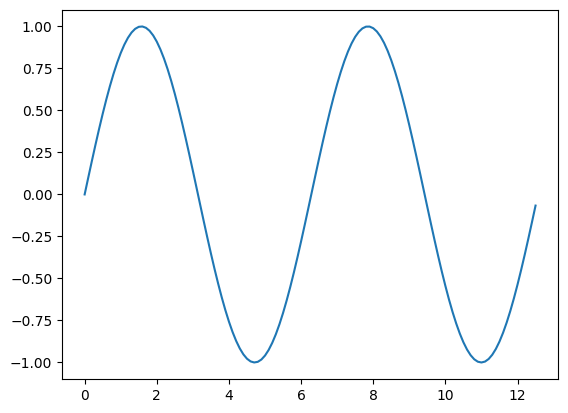

In [47]:
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y)

Of course, it's always good practice to label our axes. Let's do this and also give the plot a title.

Text(0.5, 1.0, 'A sine wave')

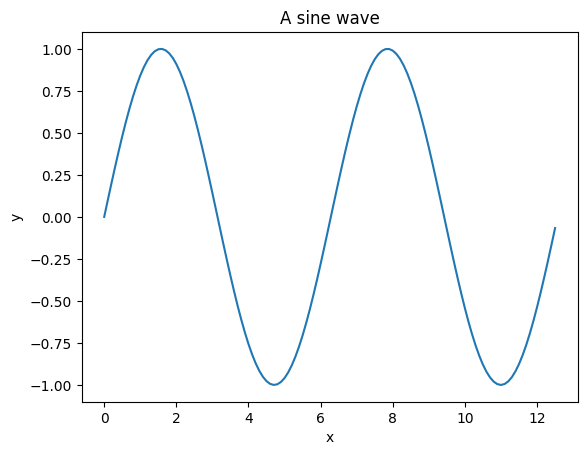

In [48]:
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('A sine wave')

If we don't want all of the points to be connected with lines, we can include an extra argument in `plt.plot` that specifies what kind of point we want to be plotted.

Text(0.5, 1.0, 'A sine wave')

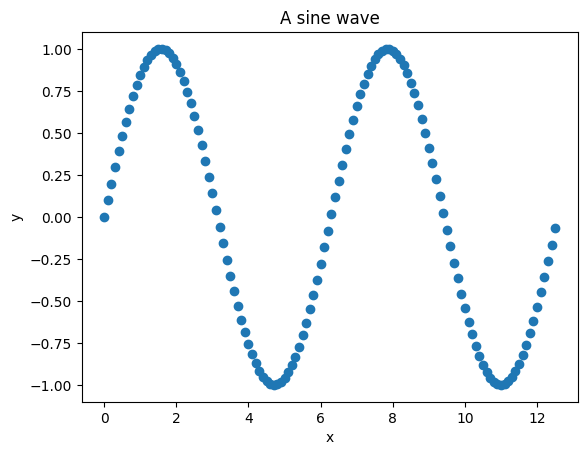

In [49]:
x = np.arange(0, 4*np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y, 'o')  # also try replacing 'o' by 's' or '.' or '--'
plt.xlabel('x')
plt.ylabel('y')
plt.title('A sine wave')

We can also plot two curves in the same figure.

Text(0.5, 1.0, 'Sine and cosine')

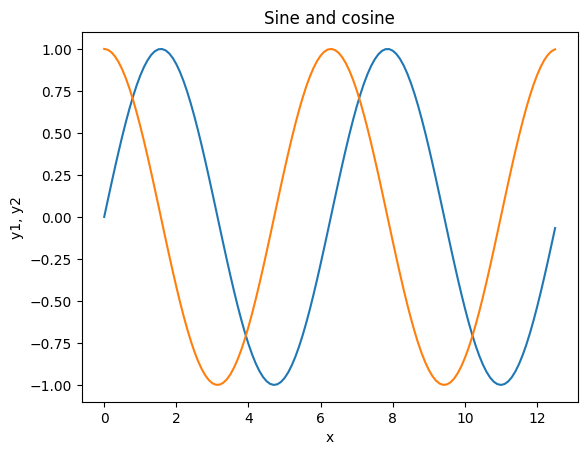

In [50]:
x = np.arange(0, 4*np.pi, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)
plt.plot(x, y1)
plt.plot(x, y2)
plt.xlabel('x')
plt.ylabel('y1, y2')
plt.title('Sine and cosine')

Each curve is automatically plotted in a different color, but we can customize colors and even add a legend if we want.

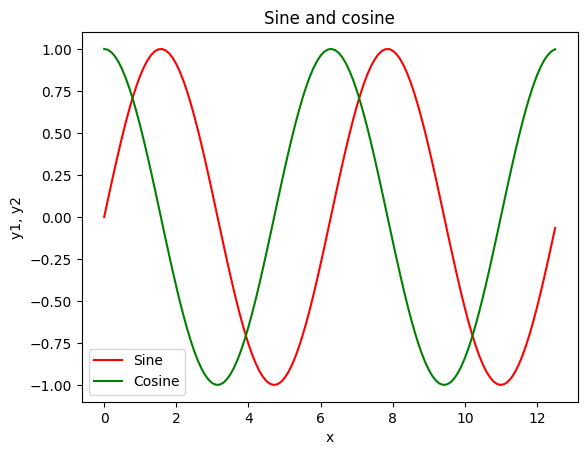

In [51]:
x = np.arange(0, 4*np.pi, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)
plt.plot(x, y1, color='r')
plt.plot(x, y2, color='g')
plt.xlabel('x')
plt.ylabel('y1, y2')
plt.title('Sine and cosine')
plt.legend(['Sine', 'Cosine'])

Matplotlib offers many, many ways to customize your plots. Take a look at lots and lots of examples here: https://matplotlib.org/2.0.2/gallery.html

## Histograms

A histogram allows us to see how data is distributed, with the height of each bar showing how many of the data points fall within each "bin". Let's generate an array of random numbers from a uniform distribution and check that we get about the same number of counts in each bin.

Text(0, 0.5, 'count')

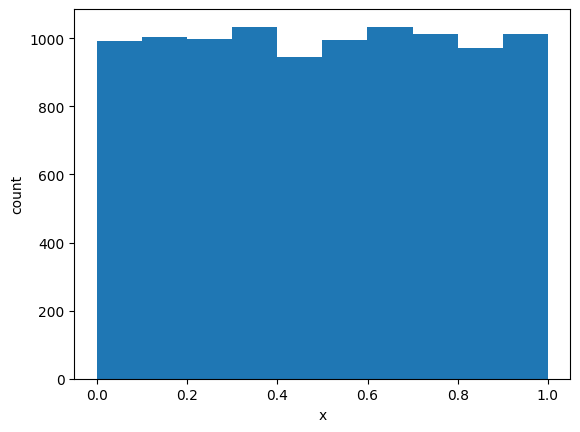

In [52]:
x = np.random.rand(10000)
plt.hist(x)
plt.xlabel('x')
plt.ylabel('count')

## Visualizing matrices

A common way to visualize two-dimensional data is as a color-coded matrix, also known as a heat map. This can be done using `plt.imshow`.

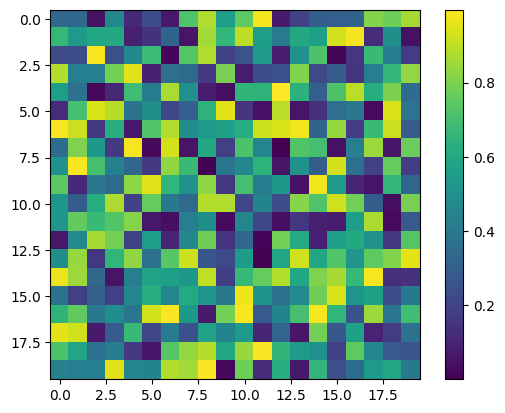

In [53]:
x = np.random.rand(20, 20)
plt.imshow(x)
plt.colorbar()  # This creates the color bar on the right hand side so we know what the colors mean

## Subplots

We can make subplots within the same plot. In the following examples, we'll illustrate two different distributions of random numbers in two different subplots. We'll also increase the number of bins in the histogram plots to show the distributions in more detail.

Text(0.5, 0, 'x')

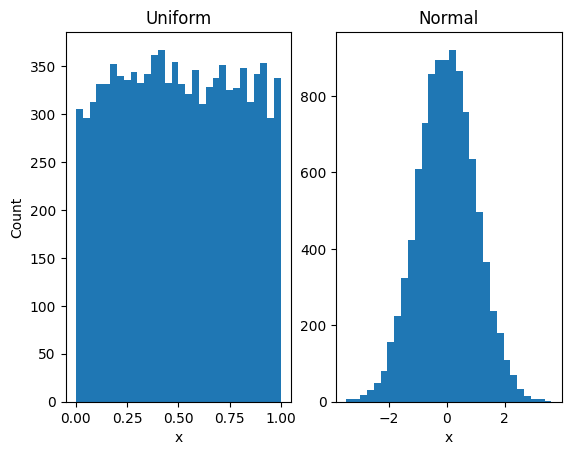

In [54]:
# Generate some random data:
x1 = np.random.rand(10000)
x2 = np.random.randn(10000)

# The first subplot:
plt.subplot(121) # the three numbers refer to the number of rows, number of columns, and which subplot we're making
plt.hist(x1, bins=30)
plt.title('Uniform')
plt.xlabel('x')
plt.ylabel('Count')

# The second subplot:
plt.subplot(122)
plt.hist(x2, bins=30)
plt.title('Normal')
plt.xlabel('x')

# Pro tip: The following line makes everything fit together more nicely.
# Try uncommenting it and compare the difference:
# plt.tight_layout()

## Error bars

When we are working with actual data, we will often want to average it (e.g. averaging over trials in a neuroscience experiment) and include error bars to illustrate how spread out the data is. Let's create some fake data in which the underlying signal is a sine wave, and each trial has noise added to it. Then we'll plot the trial-averaged data together with error bars used to denote the standard deviation. This example will also include some of what we've learned about using for loops and performing operations over arrays.

Text(0, 0.5, 'y')

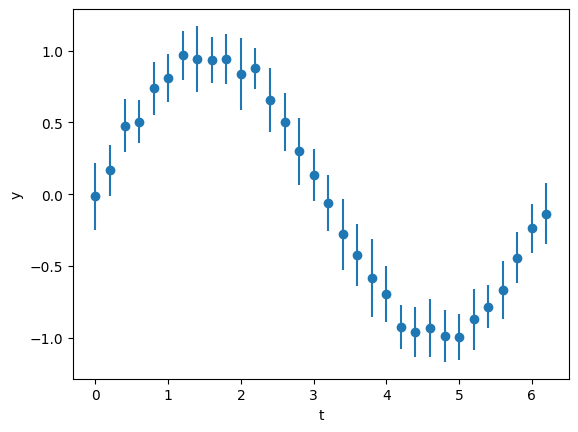

In [55]:
# Generate some fake data:
t = np.arange(0, 2*np.pi, 0.2)
signal = np.sin(t)
n_timesteps = len(t)
n_trials = 20
y = np.zeros((n_trials, n_timesteps))

# Add noise to the signal:
for i in range(n_trials):
    y[i,:] = signal + 0.2*np.random.randn(n_timesteps)

# Compute the mean and standard deviation over trials:
y_mean = np.mean(y, axis=0)
y_std = np.std(y, axis=0)

# Make the plot:
plt.errorbar(t, y_mean, yerr=y_std, fmt='o')
plt.xlabel('t')
plt.ylabel('y')